# Deep Learning to detect writed numbers

## Librairies

In [10]:
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from nn import transform
import os


In [11]:
batch_size = 16
n_epochs = 10
lr = 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
device

device(type='cpu')

## Dataset

In [13]:
dataset_path = 'dataset/'
classes = range(len(os.listdir(dataset_path)))

In [14]:
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
n_classes = len(dataset.classes)

torch.Size([1, 96, 96]) 5


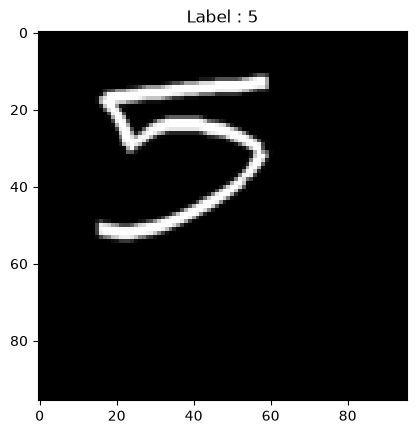

torch.Size([1, 96, 96]) 5


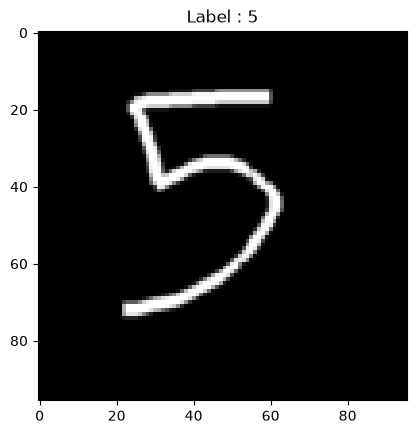

torch.Size([1, 96, 96]) 7


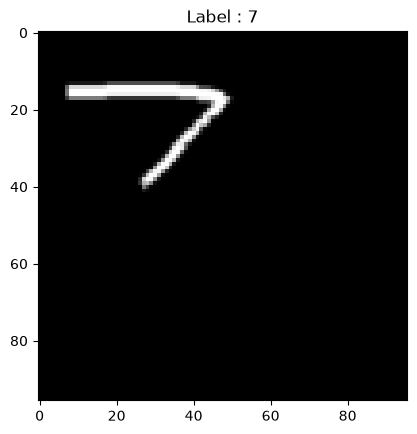

torch.Size([1, 96, 96]) 1


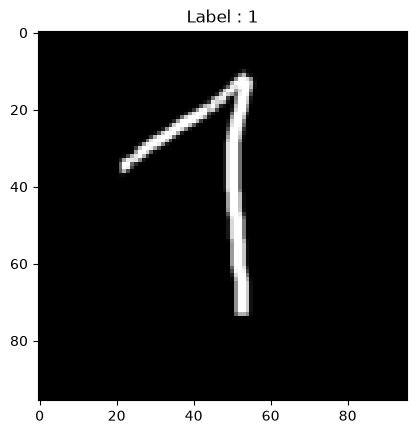

torch.Size([1, 96, 96]) 0


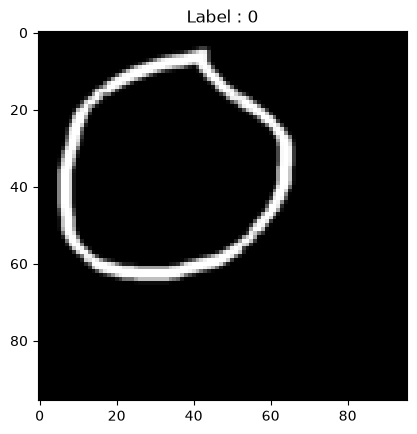

torch.Size([1, 96, 96]) 2


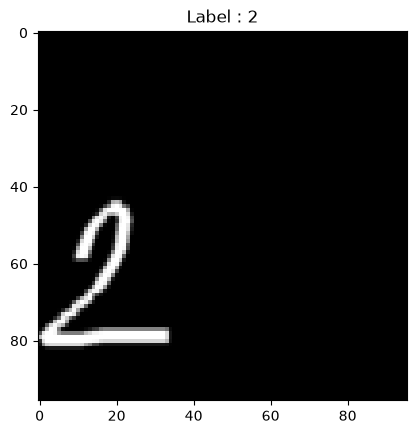

torch.Size([1, 96, 96]) 9


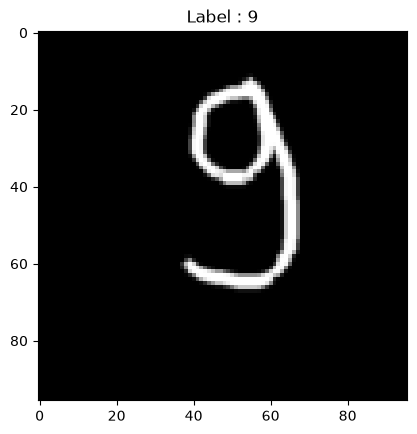

torch.Size([1, 96, 96]) 2


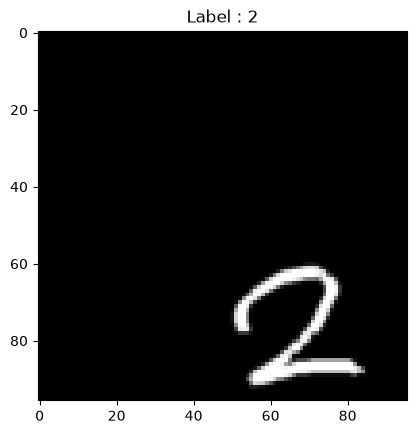

torch.Size([1, 96, 96]) 9


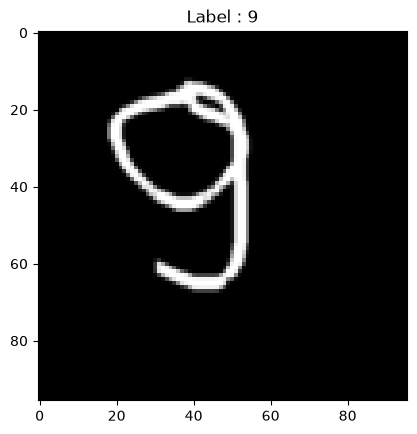

torch.Size([1, 96, 96]) 7


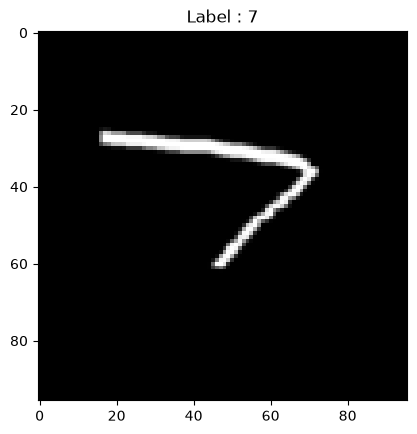

torch.Size([1, 96, 96]) 1


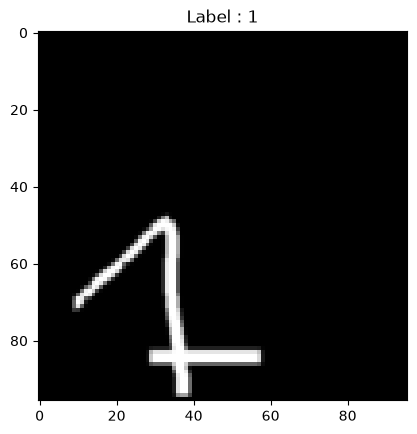

torch.Size([1, 96, 96]) 7


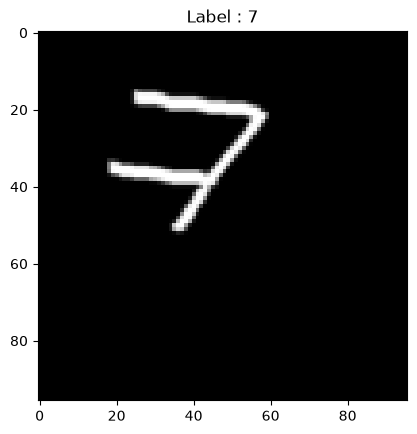

torch.Size([1, 96, 96]) 8


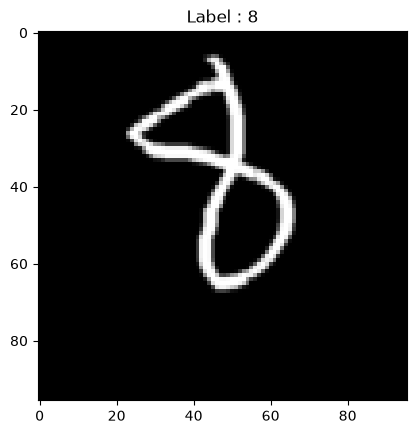

torch.Size([1, 96, 96]) 7


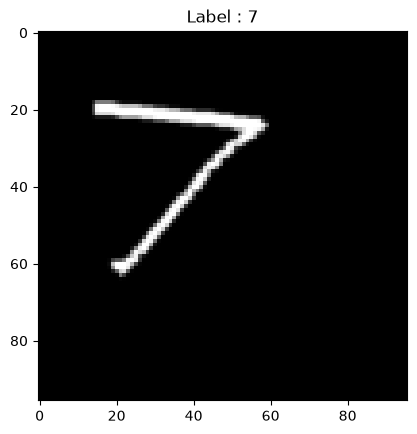

torch.Size([1, 96, 96]) 2


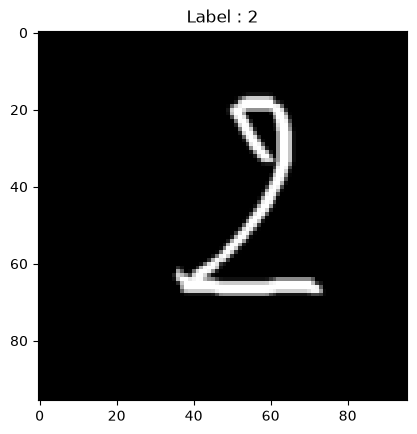

torch.Size([1, 96, 96]) 0


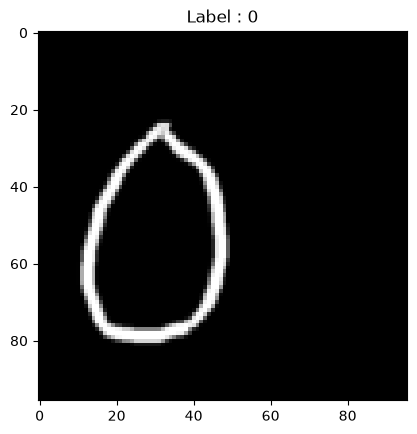

In [15]:
#Function to show an image
def imshow(img, title):
    img = img / 2 + 0.5 #unormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.show()

#Get some random training images
dataiter = iter(dataloader)
images, labels = next(dataiter)

#Show images with labels
for i in range(len(images)):
    print(images[i].shape, labels[i].item())
    imshow(images[i],title=f'Label : {labels[i].item()}')

In [16]:
#total number of images
print(len(dataset))

500


In [17]:
n_classes

10

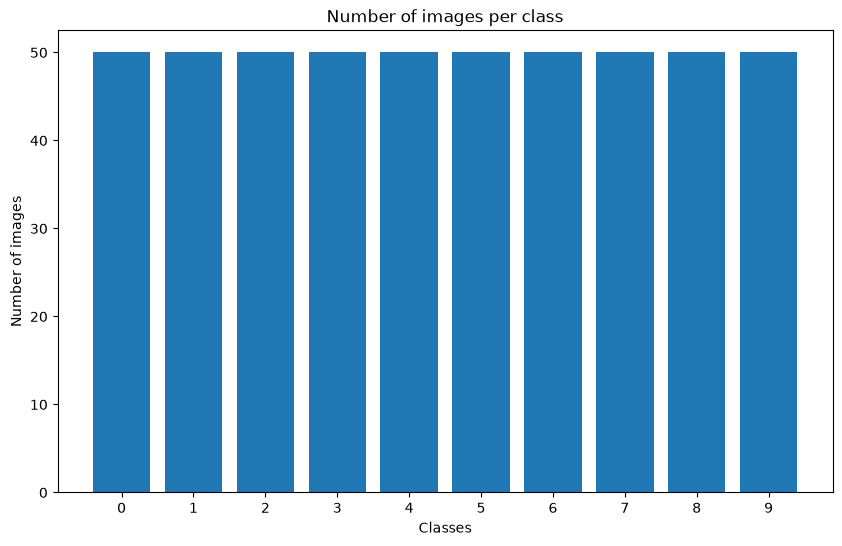

In [18]:
plt.figure(figsize=(10,6))
plt.bar(classes, [len(os.listdir(dataset_path + c)) for c in os.listdir(dataset_path)])
plt.xticks(classes)
plt.title('Number of images per class')
plt.xlabel('Classes')
plt.ylabel('Number of images')
plt.show()

## Neural Network

In [19]:
from nn import Net
net = Net(n_classes=n_classes).to(device)

In [20]:
net

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=7056, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [21]:
#number of parameters
sum(p.numel() for p in net.parameters())

860426

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

#Train the network
for epoch in range(n_epochs): #loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(dataloader):
        #get the inputs, data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = net(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    #print loss
    print(f'Epoch {epoch +1}, loss : {running_loss / len(dataloader)}')

print('Finished Training')

Epoch 1, loss : 2.3036972358822823
Epoch 2, loss : 2.30196450650692
Epoch 3, loss : 2.298267684876919
Epoch 4, loss : 2.2948261946439743
Epoch 5, loss : 2.291919395327568
Epoch 6, loss : 2.286554880440235
Epoch 7, loss : 2.2815590128302574
Epoch 8, loss : 2.272915631532669
Epoch 9, loss : 2.2630345448851585
Epoch 10, loss : 2.248264268040657
Finished Training


In [23]:
#Save the model
torch.save(net.state_dict(), 'net.pth')

## Inference

### Total accuracy and accuracy per class

In [26]:
test_dataset_path = 'testdataset/'
test_dataset = datasets.ImageFolder(root=test_dataset_path, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
n_classes = len(test_dataset.classes)
classes = range(len(os.listdir(test_dataset_path)))

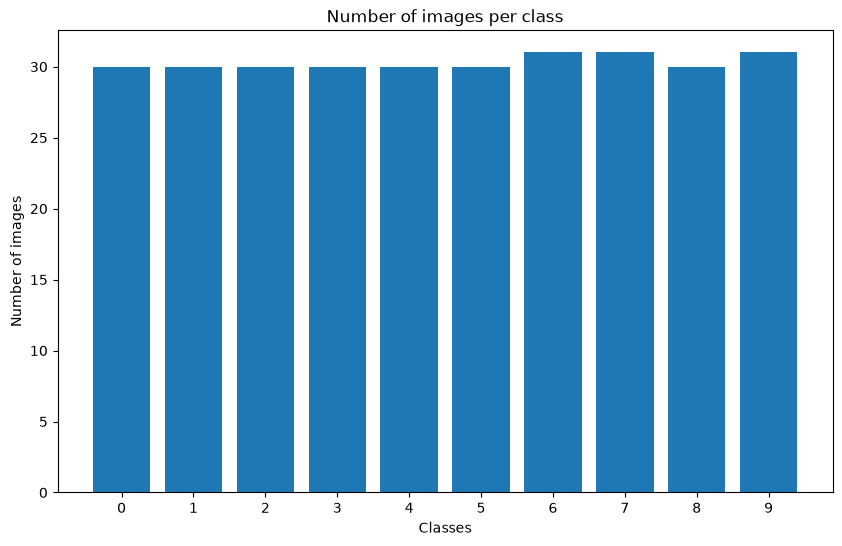

In [27]:
plt.figure(figsize=(10,6))
plt.bar(classes, [len(os.listdir(test_dataset_path + c)) for c in os.listdir(test_dataset_path)])
plt.xticks(classes)
plt.title('Number of images per class')
plt.xlabel('Classes')
plt.ylabel('Number of images')
plt.show()

In [28]:
from nn import Net
net = Net(n_classes=10).to(device)
net.load_state_dict(torch.load('net.pth'))

<All keys matched successfully>

Accuracy of the network on the test images: 42.8%
Accuracy of 0: 34.0%
Accuracy of 1: 18.0%
Accuracy of 2: 18.0%
Accuracy of 3: 6.0%
Accuracy of 4: 78.0%
Accuracy of 5: 34.0%
Accuracy of 6: 48.0%
Accuracy of 7: 74.0%
Accuracy of 8: 70.0%
Accuracy of 9: 48.0%


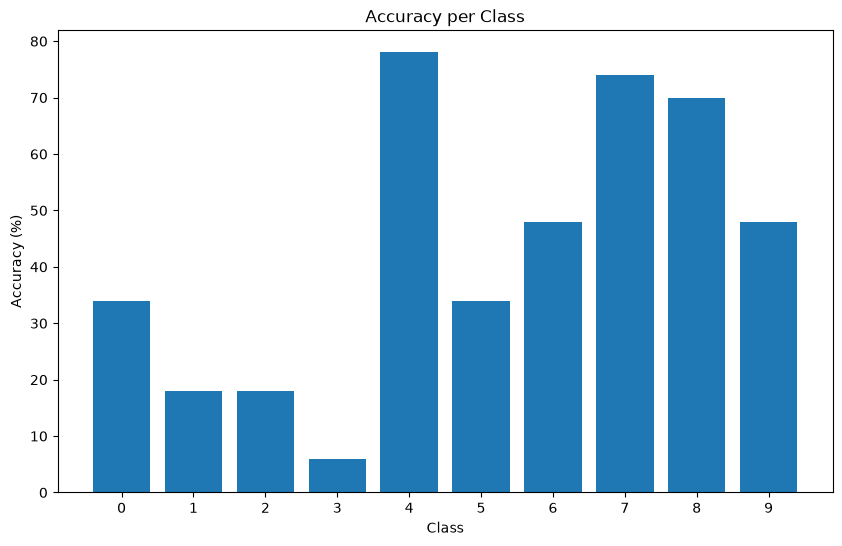

In [ ]:
#compute accuracy on this test set, and compute accuracy per class and plot histogram of the accuracy per class

correct = 0
total = 0
class_correct = list(0. for i in range(n_classes))
class_total = list(0. for i in range(n_classes))
with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test images: {100 * correct / total}%')

class_accuracies = []
for i in range(n_classes):
    accuracy = 100 * class_correct[i] / class_total[i]
    class_accuracies.append(accuracy)
    print(f'Accuracy of {test_dataset.classes[i]}: {accuracy}%')

#Plot the histogram of accuracies per class
plt.figure(figsize=(10,6))
plt.bar(range(n_classes), class_accuracies, align='center')
plt.xticks(range(n_classes), test_dataset.classes)
plt.xlabel('Class')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy per Class')
plt.show()